# Step 2 — LLM Annotation: Sentiment & Topic Analysis

This notebook explores the results of the LLM annotation pass run by `src/annotate.py`.
It assumes that:
1. `src/annotate.py` has been run and `data/llm_annotations/*.jsonl` files exist.
2. `src/aggregate_features.py` has been run and `data/features/nlp_features.parquet` exists.

**Sections:**
1. Load & inspect raw annotations
2. Sentiment time-series by source and speaker role
3. Topic heatmap across quarters
4. Representative key quotes per topic per quarter
5. Validation sample — manual label spot-check
6. NLP feature summary (what goes into Step 3)

## Contents

| Section | Description |
|---|---|
| [1. Load raw annotations](#1.-Load-raw-annotations) | Load all 3,829 annotated passages from JSONL cache; sentiment label distribution by source |
| [2. Sentiment time-series](#2.-Sentiment-time-series) | CEO/CFO/analyst/news sentiment over 20 quarters; AML quarter highlighted |
| [3. Topic heatmap](#3.-Topic-heatmap) | Topic share and sentiment heatmaps across quarters; per-topic time series |
| [4. Representative key quotes](#4.-Representative-key-quotes-per-topic) | Most positive and most negative LLM-extracted quote per topic |
| [5. Validation spot-check](#5.-Validation-sample-—-manual-spot-check) | 30 manually reviewed chunks (10 per source type) with LLM labels and quotes |
| [6. FinBERT vs LLM comparison](#6.-FinBERT-vs-LLM-—-Sentiment-Comparison) | Sign agreement (86.8%), Pearson r, confusion matrix, divergent chunk examples |
| [7. NLP feature summary](#7.-NLP-feature-summary-(Step-3-inputs)) | Quarter-level feature matrix: sentiment trends, topic entropy, missing-value heatmap |

**Data source:** `data/features/nlp_features.parquet` — 22 quarters × 35 columns  
**Annotation cache:** `data/llm_annotations/*.jsonl` (one file per source type)  
**Analysis scope:** FY2021Q2 – FY2026Q1 (20 complete quarters); FY2026Q2 excluded (incomplete)

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path('..').resolve()))
from src.config import FEATURES_DIR, LLM_ANNOTATIONS_DIR

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

SOURCE_TYPES = ['transcripts', 'news', 'reports_40f', 'reports_quarterly']
TOPICS = [
    'NIM', 'credit_quality', 'capital', 'US_retail', 'Canadian_personal',
    'wealth_wholesale', 'regulatory_AML', 'macro_outlook', 'cost_efficiency',
    'guidance', 'M_and_A', 'other',
]
print('Setup complete')

Setup complete


## 1. Load raw annotations

> **Analysis scope:** FY2021Q2 – FY2026Q1 (20 quarters). FY2026Q2 is **excluded from all charts and aggregations** in this notebook — it covers only February–April 2026, is news-only, and the quarter is not yet complete. The FY2026Q2 records are retained in `model_features_daily.parquet` to preserve the news-flow signal for Step 3 model training.

In [2]:
records = []
for src in SOURCE_TYPES:
    path = LLM_ANNOTATIONS_DIR / f'{src}.jsonl'
    if not path.exists():
        print(f'  {src}: NOT FOUND — run annotate.py first')
        continue
    n = 0
    with path.open() as fh:
        for line in fh:
            try:
                r = json.loads(line)
            except Exception:
                continue
            r['_src'] = src
            r['_sentiment'] = r.get('output', {}).get('sentiment', '')
            r['_score'] = r.get('output', {}).get('sentiment_score', None)
            r['_topics'] = r.get('output', {}).get('topics', [])
            r['_key_quote'] = r.get('output', {}).get('key_quote', '')
            r['_role'] = (r.get('speaker') or {}).get('role', '')
            r['_name'] = (r.get('speaker') or {}).get('name', '')
            records.append(r)
            n += 1
    print(f'  {src}: {n:,} annotations')

df = pd.DataFrame(records)
df['_score'] = pd.to_numeric(df['_score'], errors='coerce')
df['fiscal_quarter'] = df['fiscal_quarter'].fillna(df.get('td_fiscal_quarter_hint', ''))
print(f'\nTotal: {len(df):,} annotated chunks')
df.head(3)
# ── FY2026Q2 analysis exclusion ──────────────────────────────────────────────
# FY2026Q2 contains news articles only (Feb–Apr 2026, incomplete quarter).
# Excluded from all charts and aggregations below so partial-quarter data
# does not distort trends.  The records are retained in
# model_features_daily.parquet to preserve the news-flow signal for Step 3.
EXCL_QTRS = {'FY2026Q2'}
df_all = df.copy()          # full corpus — for reference only
df = df[~df['fiscal_quarter'].isin(EXCL_QTRS)].copy()
print(f'Analysis corpus: {len(df):,} chunks  '
      f'(excluded {len(df_all)-len(df):,} FY2026Q2 rows from charts)')
print('\n⚠  Footnote: FY2026Q2 excluded from this analysis (news-only, incomplete quarter).'
      '\n   Data is retained in model_features_daily.parquet for Step 3 training.')


  transcripts: 889 annotations
  news: 1,019 annotations
  reports_40f: 933 annotations
  reports_quarterly: 1,043 annotations

Total: 3,884 annotated chunks
Analysis corpus: 3,857 chunks  (excluded 27 FY2026Q2 rows from charts)

⚠  Footnote: FY2026Q2 excluded from this analysis (news-only, incomplete quarter).
   Data is retained in model_features_daily.parquet for Step 3 training.


In [3]:
# Sentiment label distribution by source
pd.crosstab(df['_src'], df['_sentiment'], normalize='index').round(3).style.background_gradient(cmap='RdYlGn', axis=1)

_sentiment,negative,neutral,positive
_src,,,
news,0.053000,0.185000,0.761000
reports_40f,0.078000,0.589000,0.332000
reports_quarterly,0.077000,0.573000,0.350000
transcripts,0.020000,0.462000,0.517000


## 2. Sentiment time-series

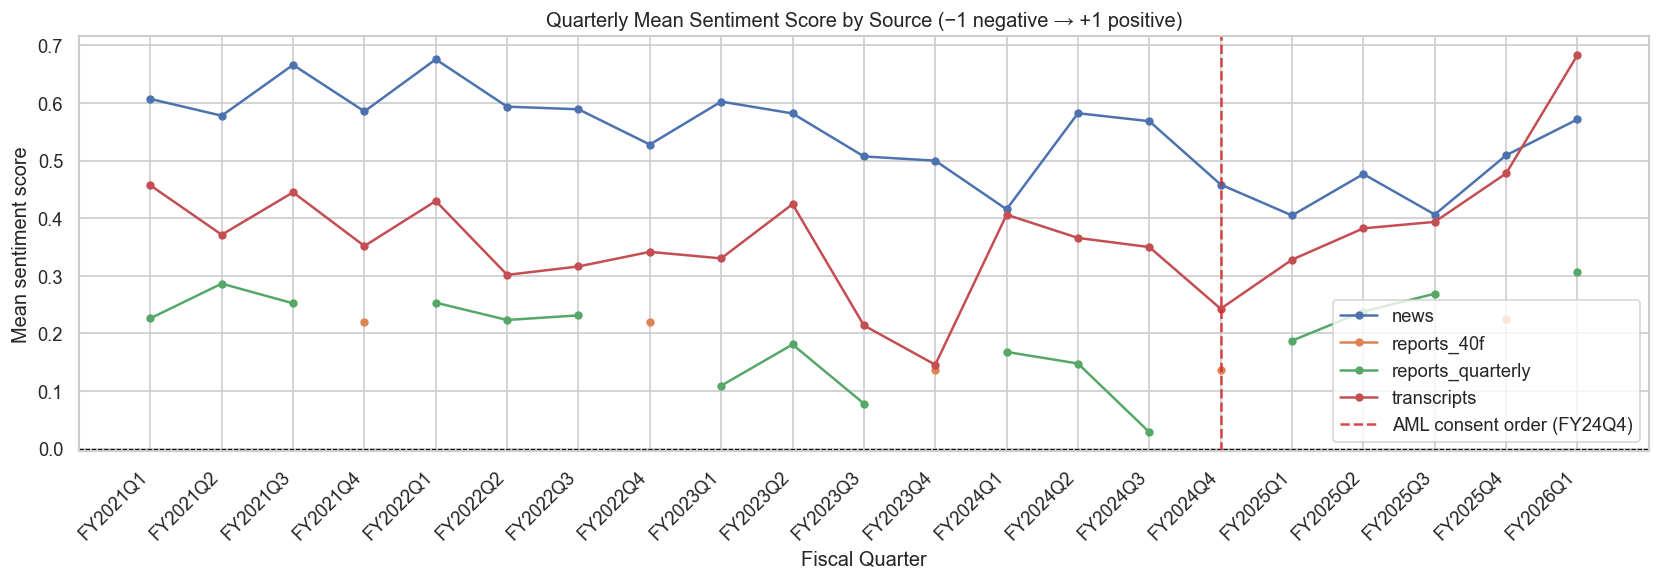

In [4]:
AML_QTR = 'FY2024Q4'

def add_aml_line(ax, quarters, label=True):
    """Add a vertical dashed red line at the AML consent-order quarter."""
    ql = list(quarters)
    if AML_QTR in ql:
        ax.axvline(
            x=ql.index(AML_QTR),
            color='#d62728', linestyle='--', linewidth=1.5, alpha=0.85,
            label='AML consent order (FY24Q4)' if label else '_nolegend_',
        )

# --- Quarterly mean sentiment by source ---
pivot = (
    df.groupby(['fiscal_quarter', '_src'])['_score']
    .mean()
    .unstack('_src')
    .sort_index()
)

quarters = list(pivot.index)
fig, ax = plt.subplots(figsize=(14, 5))
for col in pivot.columns:
    ax.plot(range(len(quarters)), pivot[col].values, marker='o', markersize=4, label=col)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
add_aml_line(ax, quarters)
ax.set_title('Quarterly Mean Sentiment Score by Source (−1 negative → +1 positive)')
ax.set_xlabel('Fiscal Quarter')
ax.set_ylabel('Mean sentiment score')
ax.set_xticks(range(len(quarters)))
ax.set_xticklabels(quarters, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


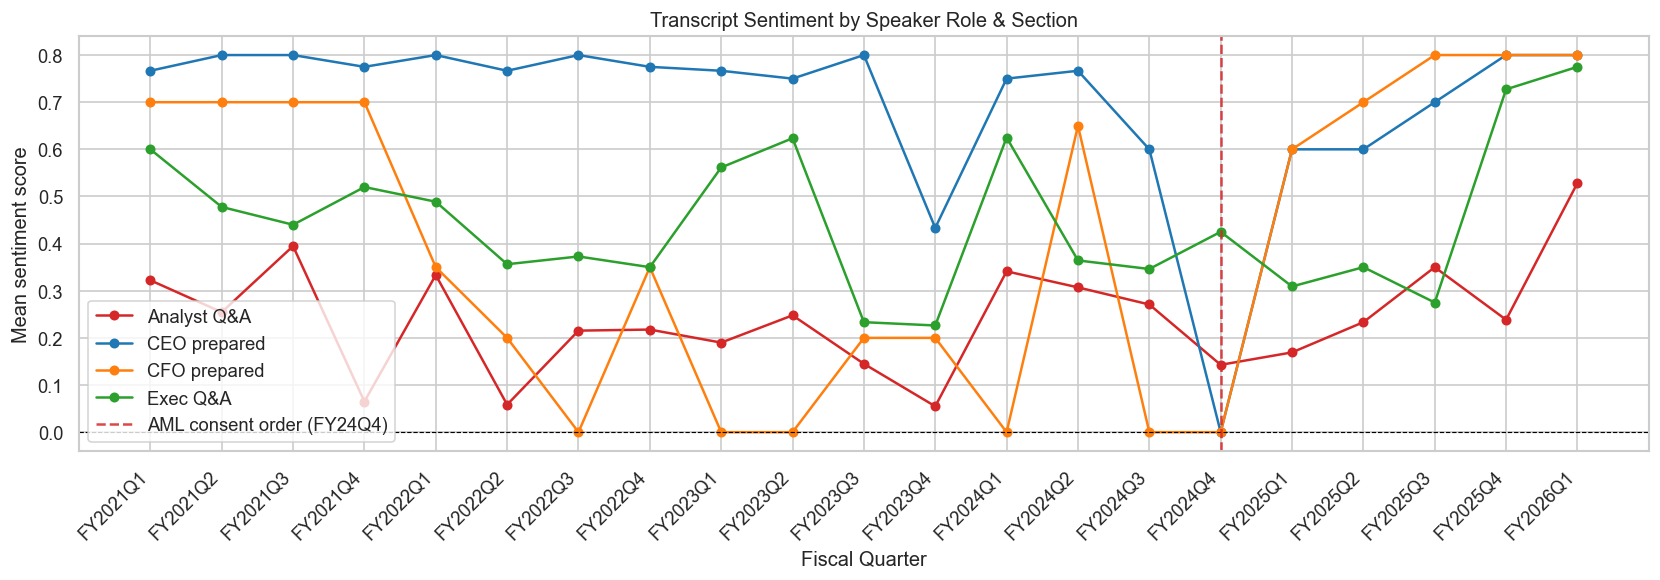

In [5]:
# --- Transcript sentiment split: CEO prep vs CFO prep vs analyst Q&A ---
tr = df[df['_src'] == 'transcripts'].copy()

def role_section_label(row):
    role = row['_role']
    sec = row.get('section', '')
    if sec == 'prepared_remarks' and role == 'ceo':  return 'CEO prepared'
    if sec == 'prepared_remarks' and role == 'cfo':  return 'CFO prepared'
    if sec == 'qa' and role == 'analyst':            return 'Analyst Q&A'
    if sec == 'qa' and role in ('ceo', 'cfo', 'other_exec'): return 'Exec Q&A'
    return None

tr['label'] = tr.apply(role_section_label, axis=1)
tr_filtered = tr[tr['label'].notna()]

pivot_tr = (
    tr_filtered.groupby(['fiscal_quarter', 'label'])['_score']
    .mean()
    .unstack('label')
    .sort_index()
)

quarters_tr = list(pivot_tr.index)
fig, ax = plt.subplots(figsize=(14, 5))
colors = {'CEO prepared': '#1f77b4', 'CFO prepared': '#ff7f0e',
          'Exec Q&A': '#2ca02c', 'Analyst Q&A': '#d62728'}
for col in pivot_tr.columns:
    ax.plot(range(len(quarters_tr)), pivot_tr[col].values,
            marker='o', markersize=5, label=col, color=colors.get(col))
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
add_aml_line(ax, quarters_tr)
ax.set_title('Transcript Sentiment by Speaker Role & Section')
ax.set_xlabel('Fiscal Quarter')
ax.set_ylabel('Mean sentiment score')
ax.set_xticks(range(len(quarters_tr)))
ax.set_xticklabels(quarters_tr, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Topic heatmap

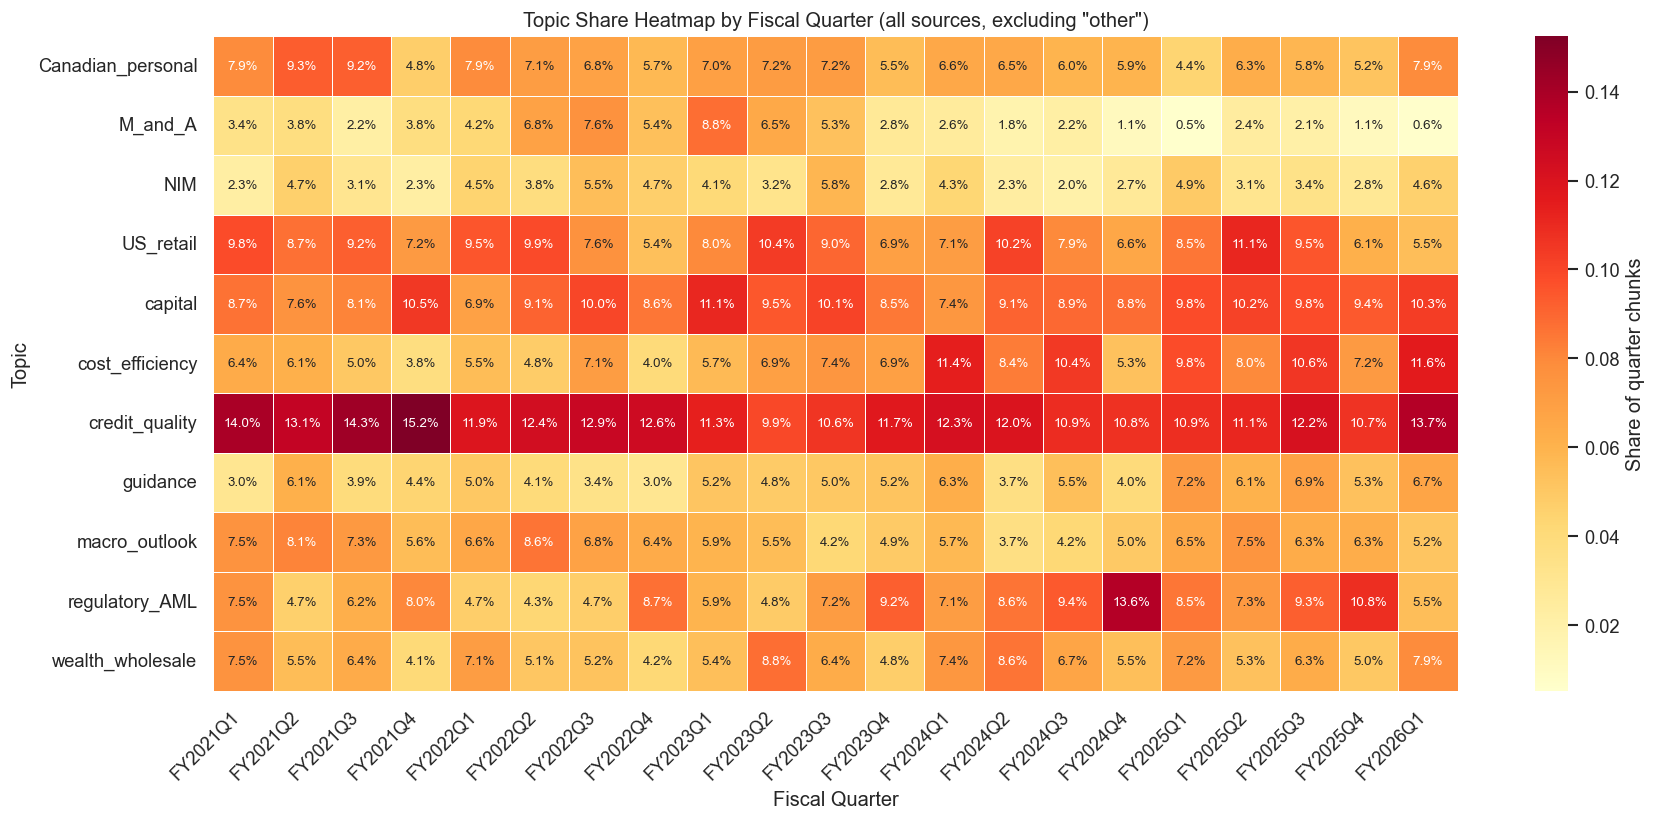

In [6]:
# Explode topics (each chunk can have multiple)
df_topics = df.explode('_topics').rename(columns={'_topics': 'topic'})
df_topics = df_topics[df_topics['topic'].isin(TOPICS)]

topic_heatmap = (
    df_topics.groupby(['fiscal_quarter', 'topic'])
    .size()
    .unstack('topic', fill_value=0)
    .sort_index()
)
# Normalise each row to show share within quarter
topic_heatmap_pct = topic_heatmap.div(topic_heatmap.sum(axis=1), axis=0)

# Drop 'other' from the plot for clarity
cols_to_show = [c for c in topic_heatmap_pct.columns if c != 'other']

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    topic_heatmap_pct[cols_to_show].T,
    ax=ax,
    cmap='YlOrRd',
    fmt='.1%',
    annot=True,
    annot_kws={'size': 8},
    linewidths=0.4,
    cbar_kws={'label': 'Share of quarter chunks'},
)
ax.set_title('Topic Share Heatmap by Fiscal Quarter (all sources, excluding "other")')
ax.set_xlabel('Fiscal Quarter')
ax.set_ylabel('Topic')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

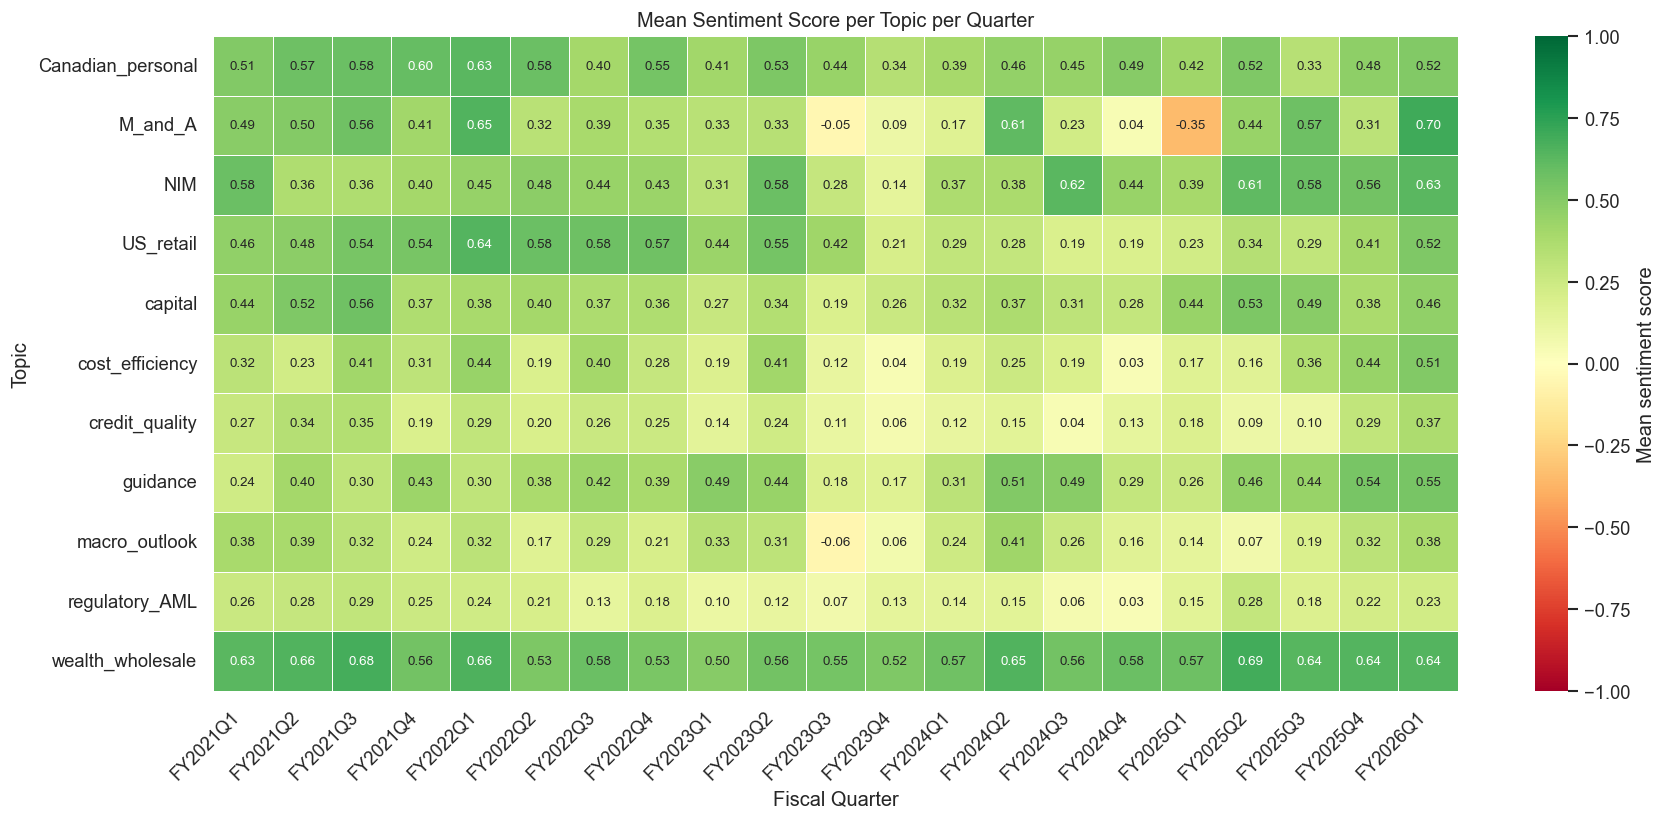

In [7]:
# Topic sentiment heatmap — is the tone around each topic positive or negative?
topic_sentiment = (
    df_topics.groupby(['fiscal_quarter', 'topic'])['_score']
    .mean()
    .unstack('topic')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    topic_sentiment[cols_to_show].T,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    fmt='.2f',
    annot=True,
    annot_kws={'size': 8},
    linewidths=0.4,
    vmin=-1, vmax=1,
    cbar_kws={'label': 'Mean sentiment score'},
)
ax.set_title('Mean Sentiment Score per Topic per Quarter')
ax.set_xlabel('Fiscal Quarter')
ax.set_ylabel('Topic')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Topic share & sentiment — per-topic time series

Each topic plotted as a quarter-by-quarter line. Red dashed line = AML consent order (FY24Q4).

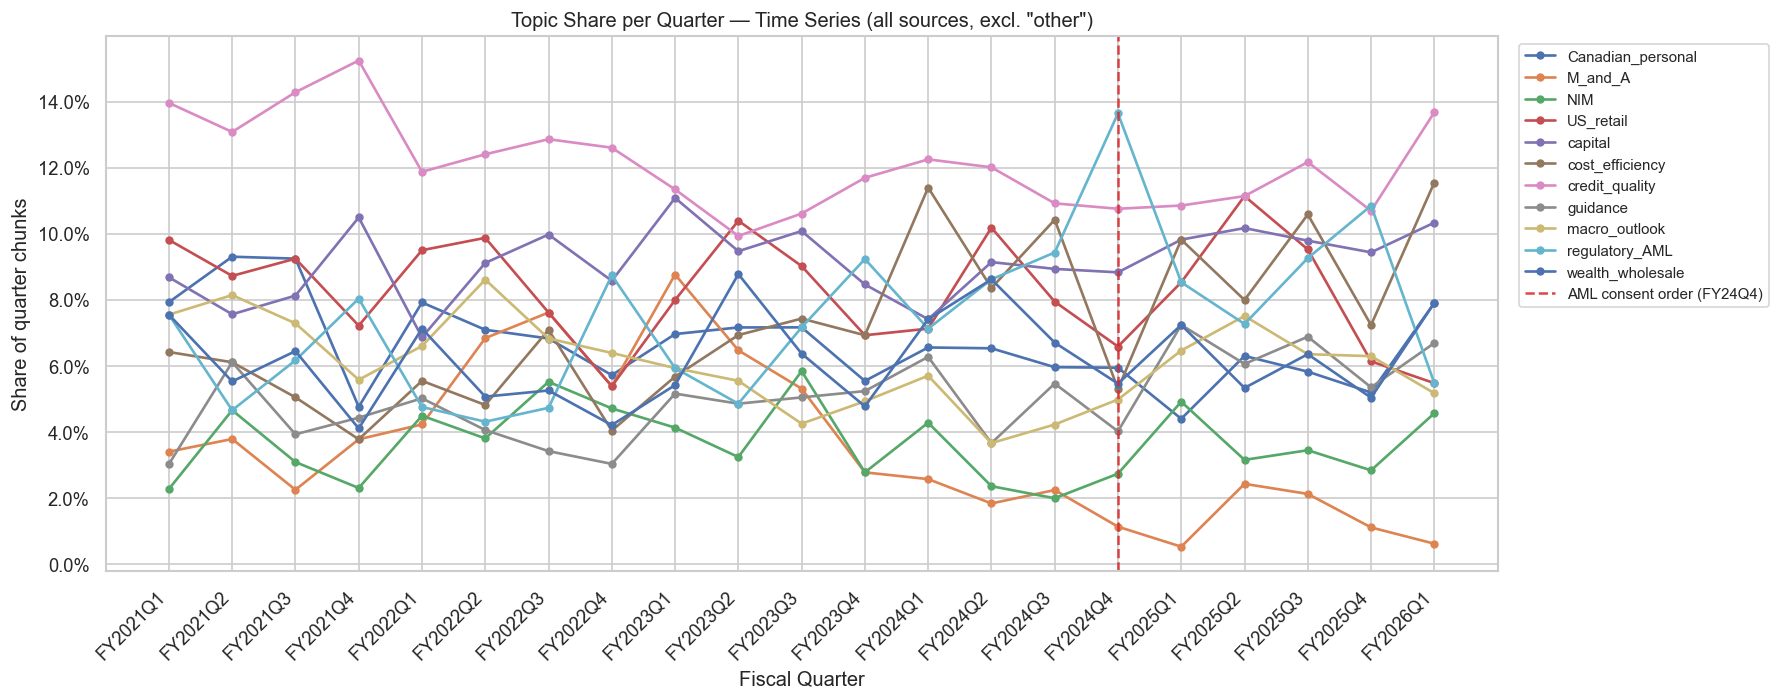

In [8]:
# ── Topic share per quarter — time series ────────────────────────────────────
quarters_t = list(topic_heatmap_pct.index)

fig, ax = plt.subplots(figsize=(15, 6))
for col in cols_to_show:
    ax.plot(range(len(quarters_t)), topic_heatmap_pct[col].values,
            marker='o', markersize=4, linewidth=1.6, label=col)
add_aml_line(ax, quarters_t)
ax.set_title('Topic Share per Quarter — Time Series (all sources, excl. "other")')
ax.set_xlabel('Fiscal Quarter')
ax.set_ylabel('Share of quarter chunks')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticks(range(len(quarters_t)))
ax.set_xticklabels(quarters_t, rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


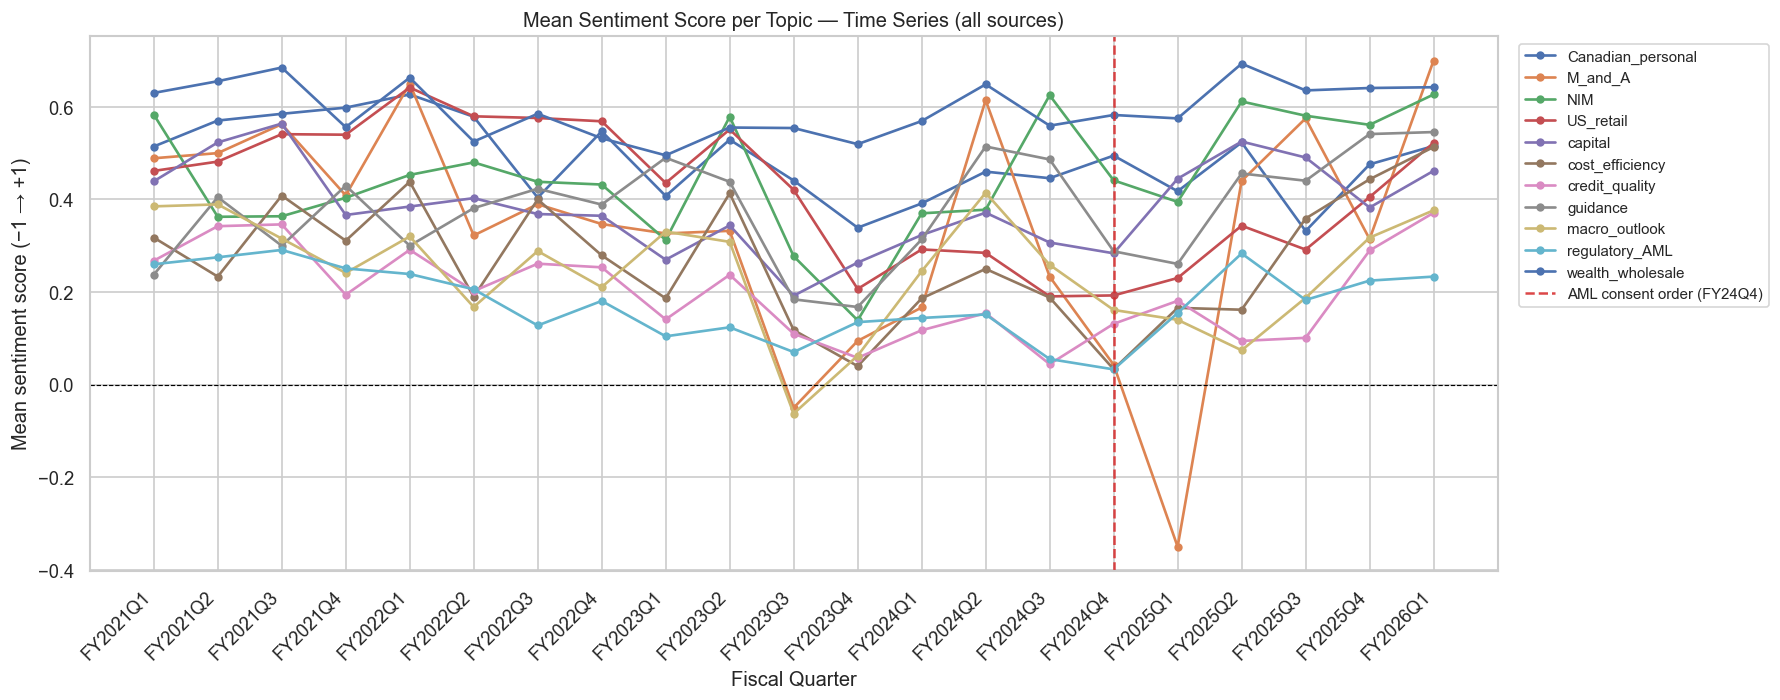

In [9]:
# ── Topic sentiment per quarter — time series ────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
for col in cols_to_show:
    vals = topic_sentiment[col].reindex(quarters_t).values
    ax.plot(range(len(quarters_t)), vals,
            marker='o', markersize=4, linewidth=1.6, label=col)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
add_aml_line(ax, quarters_t)
ax.set_title('Mean Sentiment Score per Topic — Time Series (all sources)')
ax.set_xlabel('Fiscal Quarter')
ax.set_ylabel('Mean sentiment score (−1 → +1)')
ax.set_xticks(range(len(quarters_t)))
ax.set_xticklabels(quarters_t, rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


## 4. Representative key quotes per topic

In [11]:
# For each topic, show the most negative and most positive key quote across all quarters
SHOW_TOPICS = ['NIM', 'credit_quality', 'regulatory_AML', 'macro_outlook', 'capital']

for topic in SHOW_TOPICS:
    sub = df_topics[df_topics['topic'] == topic].dropna(subset=['_score', '_key_quote'])
    if sub.empty:
        continue
    most_neg = sub.loc[sub['_score'].idxmin()]
    most_pos = sub.loc[sub['_score'].idxmax()]
    print(f'\n── {topic} ──')
    print(f'  Most positive [{most_pos["fiscal_quarter"]}] ({most_pos["_score"]:+.2f})')
    print(f'  "{most_pos["_key_quote"]}"')
    print(f'  Most negative [{most_neg["fiscal_quarter"]}] ({most_neg["_score"]:+.2f})')
    print(f'  "{most_neg["_key_quote"]}"')


── NIM ──
  Most positive [FY2022Q4] (+0.80)
  "We expect NIM to improve in the near term, assuming that the forward curves hold."
  Most negative [FY2023Q4] (-0.70)
  "Reported net income decreased by 38% compared to last year."

── credit_quality ──
  Most positive [FY2025Q2] (+0.85)
  "Total comprehensive income increased significantly compared to the previous year."
  Most negative [FY2021Q4] (-0.80)
  "The COVID-19 pandemic has negatively impacted the Bank’s results and financial condition."

── regulatory_AML ──
  Most positive [FY2024Q1] (+0.80)
  "TD's US$20 billion community impact plan supports fair lending and community investment."
  Most negative [FY2021Q4] (-0.80)
  "The COVID-19 pandemic has negatively impacted the Bank’s results and financial condition."

── macro_outlook ──
  Most positive [FY2021Q1] (+0.80)
  "TD started the year strong, with significant earnings and improved credit loss provisions."
  Most negative [FY2021Q4] (-0.80)
  "The COVID-19 pandemic has neg

## 5. Validation sample — manual spot-check

Sample 30 chunks (10 each from transcripts, news, reports_quarterly). Review the LLM label and decide if you agree.

In [12]:
# Load the original chunk text alongside annotations for comparison
import json as _json
from src.config import CHUNKS_DIR

chunk_lookup: dict[str, str] = {}
for src in SOURCE_TYPES:
    path = CHUNKS_DIR / f'{src}.jsonl'
    if not path.exists():
        continue
    with path.open() as fh:
        for line in fh:
            try:
                c = _json.loads(line)
                chunk_lookup[c['chunk_id']] = c.get('text', '')[:600]
            except Exception:
                pass

pool = df[df['_src'].isin(['transcripts', 'news', 'reports_quarterly'])].copy()
parts = []
for src_name, grp in pool.groupby('_src'):
    parts.append(grp.sample(min(10, len(grp)), random_state=42))
validation_sample = pd.concat(parts).reset_index(drop=True)

validation_sample['chunk_text_preview'] = validation_sample['chunk_id'].map(
    lambda cid: chunk_lookup.get(cid, '')[:300]
)

display_cols = ['_src', 'fiscal_quarter', '_role', '_sentiment', '_score', '_topics', '_key_quote', 'chunk_text_preview']
validation_sample[display_cols].style.set_properties(**{'text-align': 'left', 'font-size': '11px'})

,_src,fiscal_quarter,_role,_sentiment,_score,_topics,_key_quote,chunk_text_preview
0,news,FY2022Q2,,positive,0.700000,"['NIM', 'credit_quality', 'cost_efficiency']",Canadian Retail net income increased by 11% reflecting higher revenue and lower PCL.,"Results of each business segment reflect revenue, expenses, assets, and liabilities generated by the businesses in that segment. Where applicable, the Bank measures and evaluates the performance of each segment based on adjusted results and ROE, and for those segments, the Bank indicates that the me"
1,news,FY2023Q1,,positive,0.700000,['other'],TD Asset Management announces estimated annual reinvested distributions for TD ETFs.,"TD Asset Management Inc. Announces Estimated Annual Reinvested Distributions for TD ETFs 14 minute read TORONTO , Nov. 20, 2025 /CNW/ - TD Asset Management Inc. (""TDAM"") today announced the estimated 2025 reinvested distributions for TD Exchange-Traded Funds (each, a ""TD ETF"" and collectively, the"
2,news,FY2023Q4,,positive,0.800000,['other'],TD Bank Group is accepting applications for the TD Scholarship for Indigenous Peoples for 2024.,"TD Scholarship for Indigenous Peoples call for 2024 applications 3 minute read This program is tailored specifically for students from Indigenous communities, providing financial support towards post-secondary education. TORONTO , Sept. 6, 2023 /CNW/ - Today TD Bank Group (TD) and AFOA Canada are"
3,news,FY2022Q4,,positive,0.800000,['other'],TD's $10 million investment supports Canada's largest private conservation project and enhances its ESG commitment.,"TD Securities invests in Canada's largest ever private conservation project, announces formation of ESG Solutions' Carbon Advisory Practice 5 minute read $10 million investment in Nature Conservancy of Canada's work will help conserve more than 350,000 acres of Boreal forest and builds on TD's lea"
4,news,FY2021Q3,,positive,0.800000,"['Canadian_personal', 'other']",TD Insurance launches Severe Weather & Safety Alerts to help customers prepare for extreme weather.,"Be better prepared for extreme weather with new digital Severe Weather & Safety Alerts from TD Insurance 4 minute read TD Insurance Home and Auto customers now eligible to receive timely text alerts of incoming severe weather directly from their TD Insurance mobile app TORONTO , July 6, 2021 /CNW"
5,news,FY2024Q1,,neutral,0.000000,"['macro_outlook', 'US_retail', 'Canadian_personal']",The economic environment remains fluid with elevated recession risks in both the U.S. and Canada.,"As of October, the U.S. job market was still tight with the unemployment rate still historically low at 3.9%. However, there are signs that demand for workers is cooling, as evidenced by both slower trend growth in payrolls and a slight increase in the unemployment rate over the prior six months. Al"
6,news,FY2022Q4,,neutral,0.000000,"['M_and_A', 'regulatory_AML', 'guidance']",Forward-looking statements pertain to future operations and are subject to significant uncertainties.,"This communication contains certain ""forward-looking statements"" within the meaning of the Private Securities Litigation Reform Act of 1995, Section 27A of the Securities Act of 1933, as amended (the ""Securities Act""), and Section 21E of the Securities Exchange Act of 1934, as amended, (the ""Exchang"
7,news,FY2021Q4,,positive,0.800000,"['capital', 'other']","TD Bank Group declared dividends for common and preferred shares for the quarter ending October 31, 2021.","TD BANK GROUP DECLARES DIVIDENDS 4 minute read (all amounts in Canadian dollars) TORONTO , Feb. 26, 2026 /CNW/ - The Toronto-Dominion Bank (the ""Bank"") today announced that a dividend in an amount of one dollar and eight cents ($1.08) per fully paid common share in the capital stock of the Bank h"
8,news,FY2021Q3,,positive,0.700000,['other'],TD Asset Management announces cash distributions for various TD Exchange-Traded Funds.,"TD Asset Management Inc. Announces TD ETF Distributions 11 minu

## 6. FinBERT vs LLM — Sentiment Comparison

FinBERT (`ProsusAI/finbert`) is run on the same 856 transcript chunks as an independent domain-specific baseline. Sign agreement ≥ 85% = strong validation. See `README.md` for methodology.

Transcript chunks: 856  |  Opinionated: 205  |  Sign agreement: 86.8%  |  Pearson r: 0.501  |  Divergent: 27


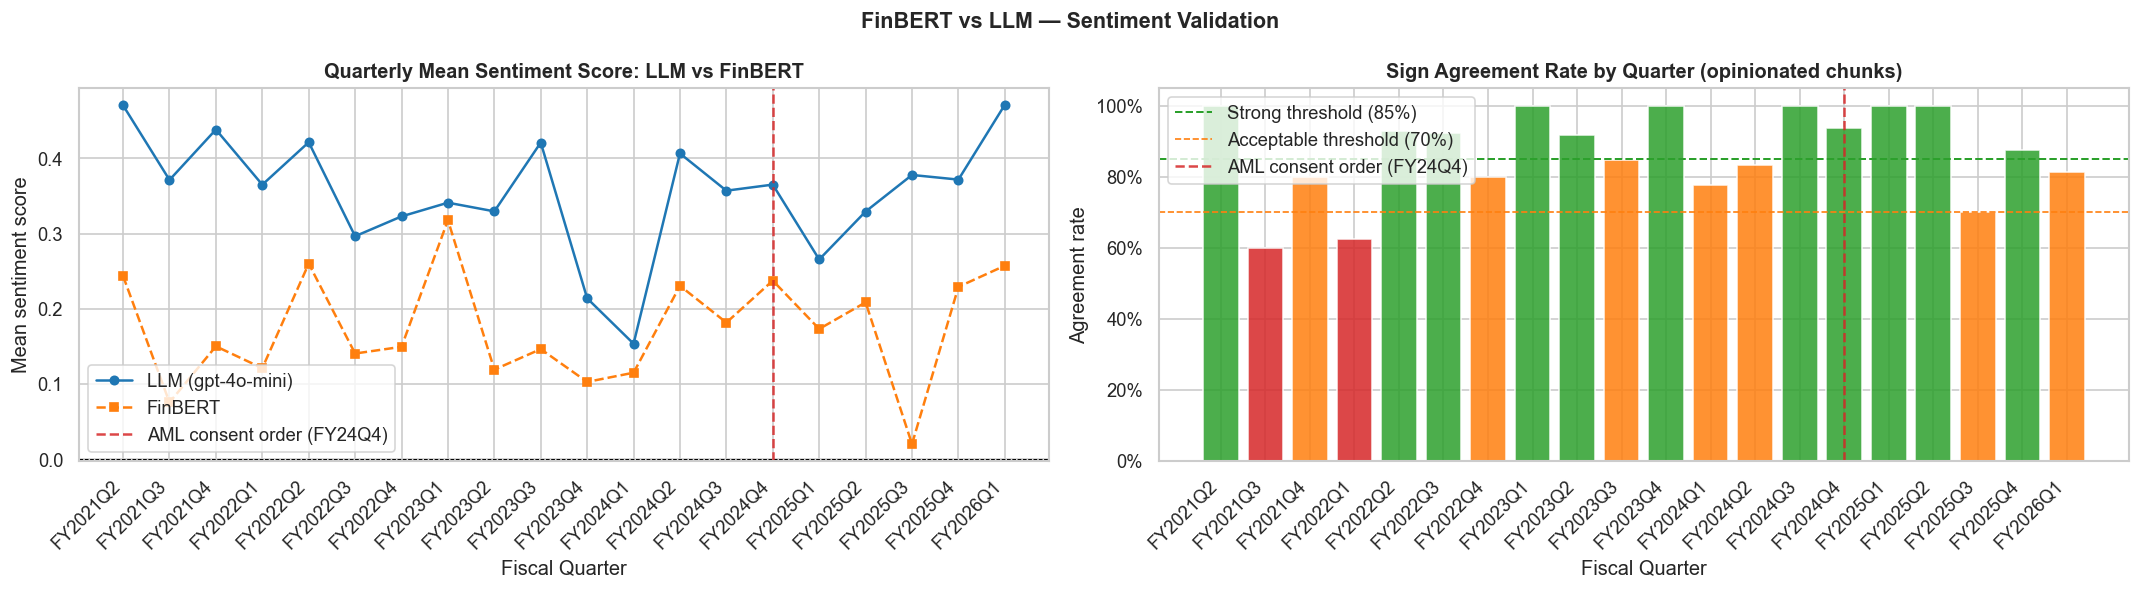

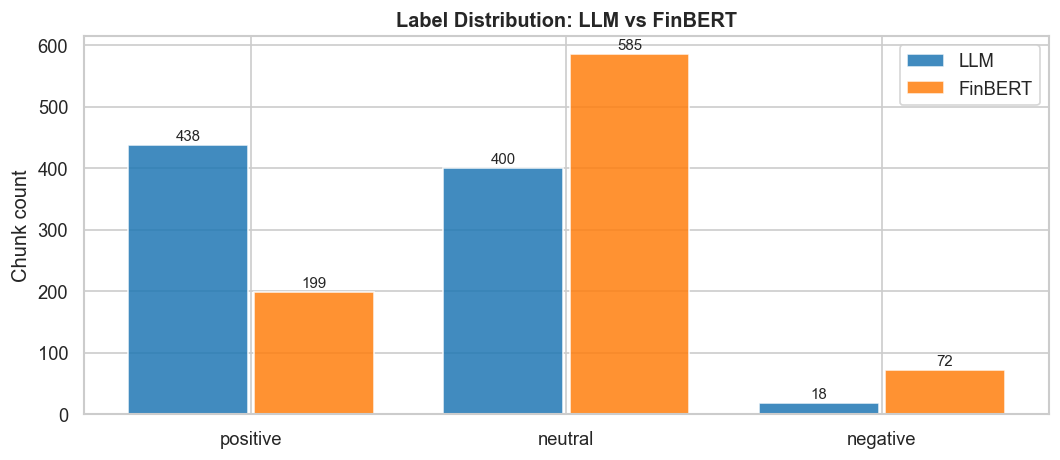


=== Top divergent chunks (LLM=positive, FinBERT=negative, n=27) ===


,Quarter,Role,LLM score,FinBERT score
771,FY2025Q3,other_exec,0.7,-0.890152
755,FY2025Q3,other_exec,0.7,-0.884800
841,FY2026Q1,other,0.7,-0.814260
230,FY2022Q3,other_exec,0.7,-0.778333
435,FY2023Q3,other,0.7,-0.746459
86,FY2021Q4,analyst,0.6,-0.732952
54,FY2021Q3,other,0.7,-0.644706
511,FY2024Q1,other,0.6,-0.629591



Pattern: All divergences share optimistic management framing paired with
risk-context words (pandemic, regulatory, losses) that FinBERT anchors
on negatively. The LLM correctly reads the management intent.


In [13]:
# ── Load FinBERT comparison data ─────────────────────────────────────────────
fb_path = FEATURES_DIR / 'finbert_comparison_transcripts.parquet'
assert fb_path.exists(), 'Run finbert_compare.py first to generate comparison file'
fb = pd.read_parquet(fb_path)

# ── Top-line metrics ──────────────────────────────────────────────────────────
opinionated = fb[fb['sign_agree'].notna()]
agreement   = opinionated['sign_agree'].mean()
n_chunks    = len(fb)
n_opin      = len(opinionated)
pearson_r   = fb[['llm_score','finbert_score']].dropna().corr().iloc[0,1]
divergent   = opinionated[opinionated['sign_agree'] == False]
print(f'Transcript chunks: {n_chunks}  |  Opinionated: {n_opin}  '
      f'|  Sign agreement: {agreement:.1%}  |  Pearson r: {pearson_r:.3f}  '
      f'|  Divergent: {len(divergent)}')

# ── Quarterly mean score comparison ───────────────────────────────────────────
fb_q = (
    fb[~fb['fiscal_quarter'].isin(EXCL_QTRS)]
    .groupby('fiscal_quarter')
    .agg(llm_mean=('llm_score','mean'), fb_mean=('finbert_score','mean'))
    .sort_index()
)
qs = list(fb_q.index)
xs = range(len(qs))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: score comparison
ax = axes[0]
ax.plot(xs, fb_q['llm_mean'].values, marker='o', markersize=5, label='LLM (gpt-4o-mini)', color='#1f77b4')
ax.plot(xs, fb_q['fb_mean'].values,  marker='s', markersize=5, label='FinBERT', color='#ff7f0e', linestyle='--')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
add_aml_line(ax, qs)
ax.set_title('Quarterly Mean Sentiment Score: LLM vs FinBERT', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean sentiment score')
ax.set_xticks(xs); ax.set_xticklabels(qs, rotation=45, ha='right')
ax.legend(); ax.set_xlabel('Fiscal Quarter')

# Right: quarterly agreement rate
agr_q = (
    opinionated[~opinionated['fiscal_quarter'].isin(EXCL_QTRS)]
    .groupby('fiscal_quarter')['sign_agree']
    .mean()
    .reindex(qs)
)
ax2 = axes[1]
bars = ax2.bar(xs, agr_q.values, color=[
    '#2ca02c' if (v is not None and v >= 0.85)
    else '#ff7f0e' if (v is not None and v >= 0.70)
    else '#d62728' if v is not None else '#cccccc'
    for v in agr_q.values
], alpha=0.85)
ax2.axhline(0.85, color='#2ca02c', linestyle='--', linewidth=1.2, label='Strong threshold (85%)')
ax2.axhline(0.70, color='#ff7f0e', linestyle='--', linewidth=1.0, label='Acceptable threshold (70%)')
add_aml_line(ax2, qs)
ax2.set_title('Sign Agreement Rate by Quarter (opinionated chunks)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Agreement rate')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_xticks(xs); ax2.set_xticklabels(qs, rotation=45, ha='right')
ax2.legend(); ax2.set_xlabel('Fiscal Quarter')

plt.suptitle('FinBERT vs LLM — Sentiment Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Label distribution comparison ─────────────────────────────────────────────
llm_dist = fb['llm_sentiment'].value_counts().reindex(['positive','neutral','negative'], fill_value=0)
fb_dist  = fb['finbert_label'].value_counts().reindex(['positive','neutral','negative'], fill_value=0)
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(3)
ax.bar(x - 0.2, llm_dist.values, 0.38, label='LLM', color='#1f77b4', alpha=0.85)
ax.bar(x + 0.2, fb_dist.values,  0.38, label='FinBERT', color='#ff7f0e', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['positive','neutral','negative'])
ax.set_title('Label Distribution: LLM vs FinBERT', fontsize=12, fontweight='bold')
ax.set_ylabel('Chunk count'); ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())) if bar.get_height() > 0 else '', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

# ── Divergent chunks table ─────────────────────────────────────────────────────
print(f'\n=== Top divergent chunks (LLM=positive, FinBERT=negative, n={len(divergent)}) ===')
div_show = (
    divergent[divergent['llm_sentiment']=='positive']
    .sort_values('finbert_score')
    [['fiscal_quarter','speaker_role','llm_score','finbert_score']]
    .head(8)
    .rename(columns={'fiscal_quarter':'Quarter','speaker_role':'Role',
                     'llm_score':'LLM score','finbert_score':'FinBERT score'})
)
display(div_show)
print('\nPattern: All divergences share optimistic management framing paired with'
      '\nrisk-context words (pandemic, regulatory, losses) that FinBERT anchors'
      '\non negatively. The LLM correctly reads the management intent.')


## 7. NLP feature summary (Step 3 inputs)

In [14]:
feat_path = FEATURES_DIR / 'nlp_features.parquet'
if not feat_path.exists():
    print('Run aggregate_features.py first: python -m src.analysis.aggregate_features')
else:
    feat = pd.read_parquet(feat_path)
    print(f'Feature matrix: {feat.shape[0]} quarters × {feat.shape[1]} columns')
    feat.head()

Feature matrix: 21 quarters × 36 columns


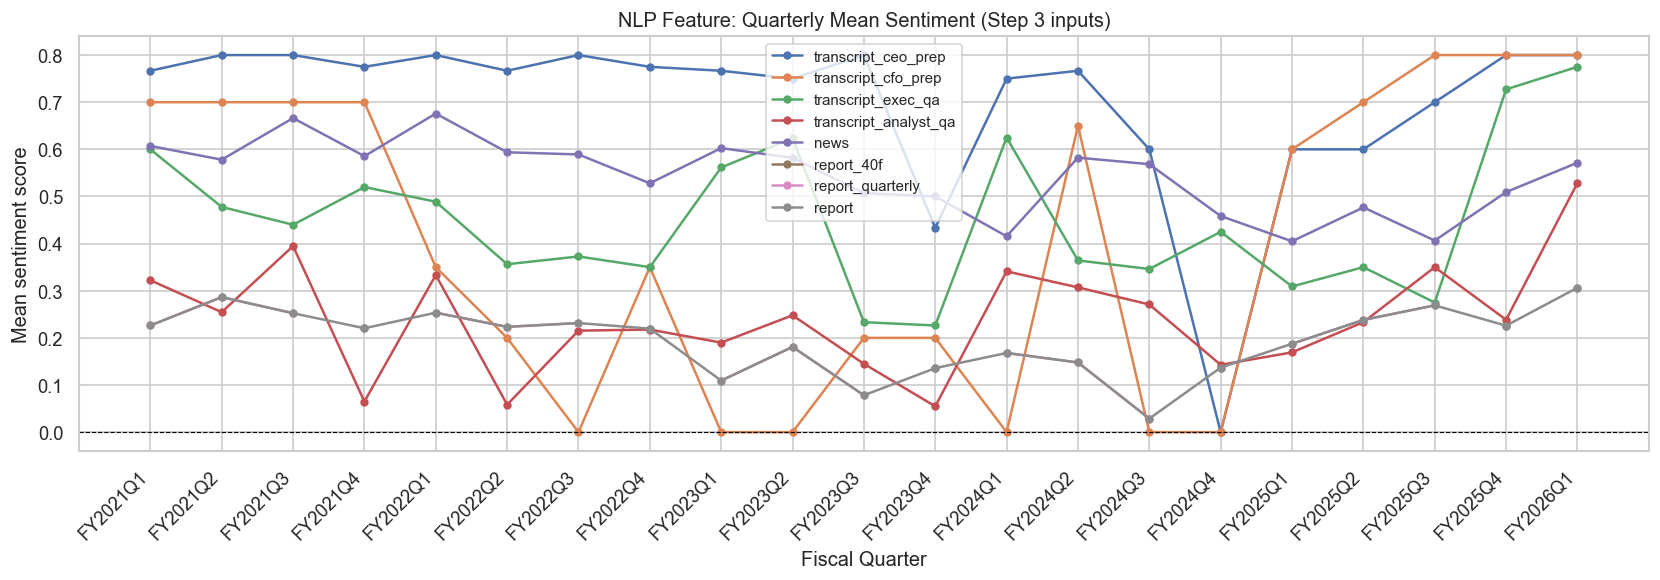

In [15]:
if feat_path.exists():
    # Sentiment columns over time
    sent_cols = [c for c in feat.columns if 'sentiment_mean' in c]
    fig, ax = plt.subplots(figsize=(14, 5))
    for col in sent_cols:
        ax.plot(feat['fiscal_quarter'], feat[col], marker='o', markersize=4, label=col.replace('_sentiment_mean', ''))
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title('NLP Feature: Quarterly Mean Sentiment (Step 3 inputs)')
    ax.set_xlabel('Fiscal Quarter')
    ax.set_ylabel('Mean sentiment score')
    ax.legend(fontsize=9)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

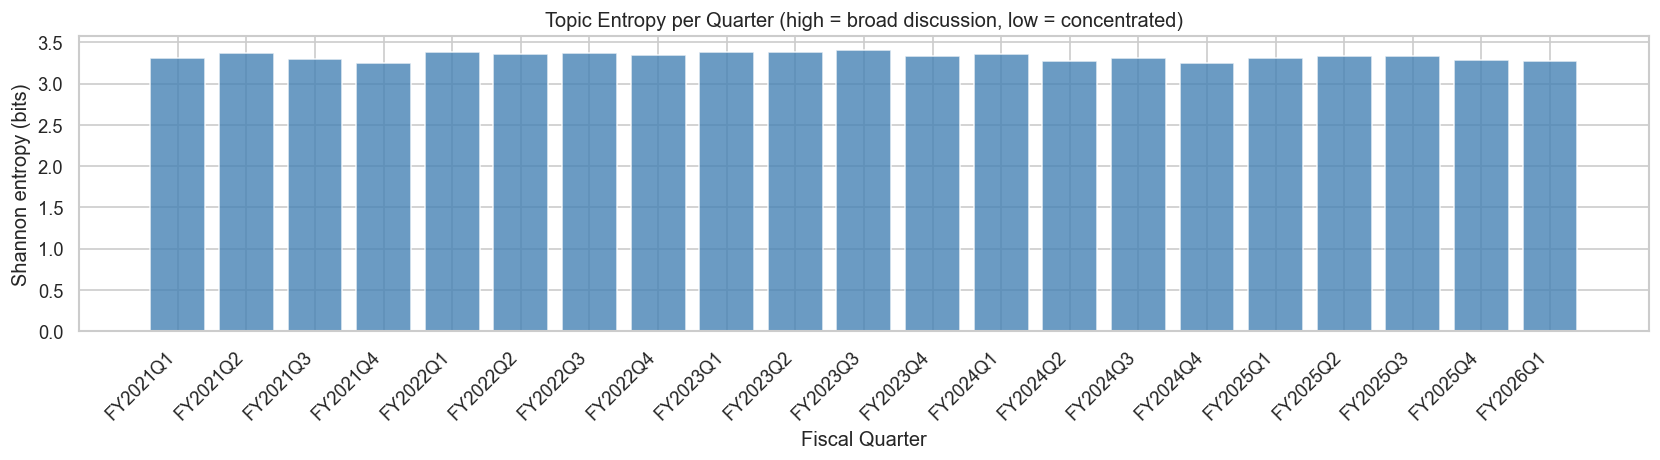

In [16]:
if feat_path.exists():
    # Topic entropy — how concentrated is the narrative each quarter?
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(feat['fiscal_quarter'], feat['topic_entropy'], color='steelblue', alpha=0.8)
    ax.set_title('Topic Entropy per Quarter (high = broad discussion, low = concentrated)')
    ax.set_xlabel('Fiscal Quarter')
    ax.set_ylabel('Shannon entropy (bits)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [17]:
if feat_path.exists():
    # Full feature matrix — show missing values heatmap
    numeric_cols = feat.select_dtypes(include='number').columns
    missing_pct = feat[numeric_cols].isna().mean()
    print('Columns with missing values:')
    print(missing_pct[missing_pct > 0].sort_values(ascending=False).to_string())
    if (missing_pct > 0).sum() == 0:
        print('No missing values — feature matrix is complete.')

Columns with missing values:
report_40f_sentiment_mean          0.761905
report_quarterly_sentiment_mean    0.238095
